In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor


In [37]:
# 데이터 수집(가져오기)
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])

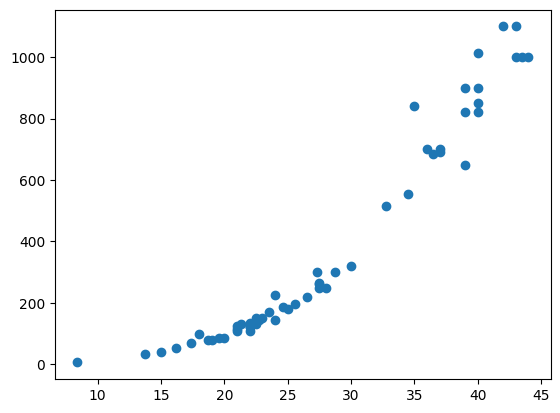

In [41]:
# 데이터 시각화 해보기
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.show()

In [29]:
# 훈련 데이터 테스트 데이터 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [30]:
# 데이터 전처리 => 모델이 원하는 입력 형태로 만들어주기 위해
train_input = train_input.reshape(-1,1) # 형태(구조)를 변경해준다. 1차원 -> 2차원 행렬로
test_input = test_input.reshape(-1,1)

In [31]:
model = KNeighborsRegressor()

In [32]:
# 학습! 사이킷런 모델은 X(Feature) 데이터로 2차원 배열을 입력받기 원함
model.fit(train_input, train_target) # 이때 테스트는 안들어감

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
# 예측
model.predict([[29]])

array([248.])

In [ ]:
# 평가 : R^2 결정계수
model.score(test_input, test_target)

0.992809406101064

In [ ]:
from sklearn.metrics import mean_absolute_error

test_prediction = model.predict(test_input) # 예측한 결과 값
mae = mean_absolute_error(test_target, test_prediction) # MAE 지표를 계산
print(mae)   # 19.16

19.157142857142862


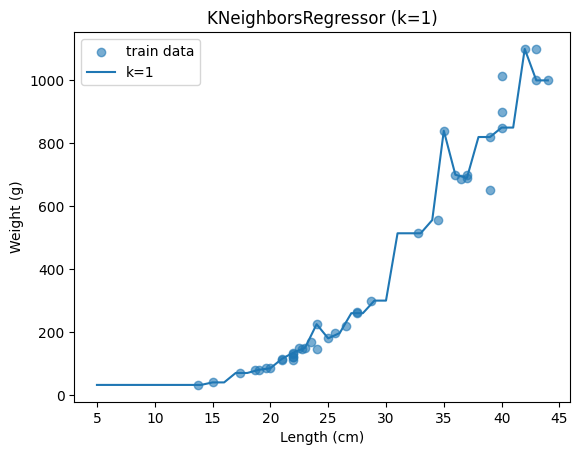

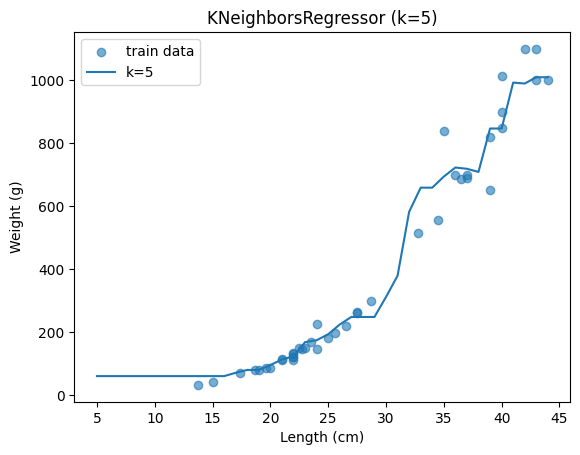

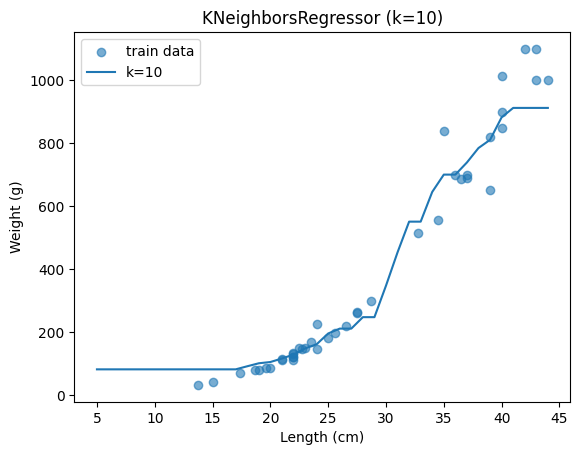

In [ ]:
# K 값의 변화에 따라서 그래프를 그려보자.
# K 값이 1, 5, 10일때 각각의 차이

model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)

for n in [1, 5, 10]:
    model.n_neighbors = n
    model.fit(train_input, train_target)
    prediction = model.predict(x)

    plt.scatter(train_input, train_target, alpha=0.6, label='train data')
    plt.plot(x, prediction, label=f'k={n}')
    plt.xlabel('Length (cm)')
    plt.ylabel('Weight (g)')
    plt.title(f'KNeighborsRegressor (k={n})')
    plt.legend()
    plt.show()

# 선형 회귀
-----------

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_input, train_target)

# 예측
print(model.predict([[100]]))
# 평가
model.score(test_input, test_target) # 결정계수 R^2


[3192.69585141]


0.824750312331356

In [53]:
# w 기울기
print("w: ", model.coef_)
# b 절편
print("b: ", model.intercept_)

w:  [39.01714496]
b:  -709.0186449535474


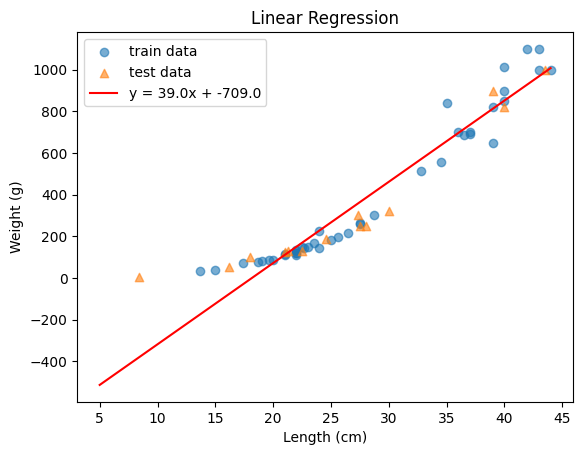

In [ ]:
# 그래프 그리기 (회귀선이 담긴 그래프 그려줘)
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(train_input, train_target)

# 회귀선용 x 범위
x = np.arange(5, 45).reshape(-1, 1)
prediction = model.predict(x)

# 그래프
plt.scatter(train_input, train_target, alpha=0.6, label='train data')
plt.scatter(test_input, test_target, alpha=0.6, marker='^', label='test data')
plt.plot(x, prediction, color='red', label=f'y = {model.coef_[0]:.1f}x + {model.intercept_:.1f}')

plt.xlabel('Length (cm)')
plt.ylabel('Weight (g)')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [ ]:
print(model.score(test_input, test_target)) # 테스트 데이터 평가 -> 0.82
print(model.score(train_input, train_target)) # 훈련 데이터 평가 -> 0.94

0.824750312331356
0.9398463339976041


In [ ]:
# MSE : 평균 제곱 오차  -> 손실함수
from sklearn.metrics import mean_squared_error

mean_squared_error(test_target, test_prediction) # 721
# 손실함수를 최소화 시키는 것이 선형 회귀의 학습이다.

721.7385714285714

# 다항회귀

In [79]:
# 방법 1: 수동 (Ch03-2)
train_poly = np.column_stack((train_input**2, train_input))
print(train_poly[:2])

# 방법 2: PolynomialFeatures (Ch03-3)
# 전처리 도구 - Feature를 자동으로 생성해준다
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(include_bias=False) # 절편은 포함시키지 않음
poly.fit(train_input)                          # train에만 fit
train_poly = poly.transform(train_input)
test_poly  = poly.transform(test_input)        # transform만
print(train_poly[:2])

[[384.16  19.6 ]
 [484.    22.  ]]
[[ 19.6  384.16]
 [ 22.   484.  ]]


In [80]:
model = LinearRegression()
model.fit(train_poly, train_target) # 2차원, 1차원 데이터 -> 예측
model.predict([[50, 50**2]]) # 예측 50cm 농어의 예측된 무게는? 1573

array([1573.98423528])

In [83]:
# parameter 를 구해본다
print(model.coef_) # w 가중치 [ x^2, x] 계수
print(model.intercept_) # b : y절편

[-21.55792498   1.01433211]
116.05021078278372


### 2차 방정식
$ 1.01x^2 - 21x + 116 $

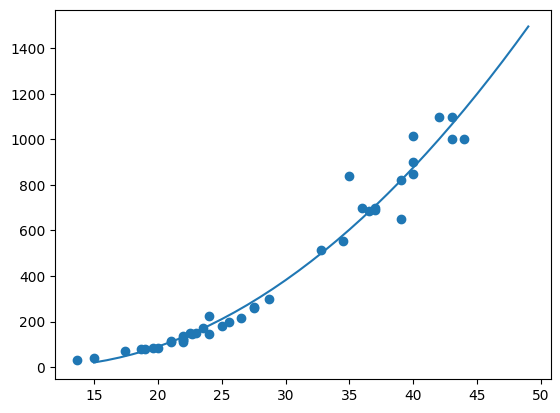

In [85]:
# 시각화
point = np.arange(15,50) # 점의 범위 범위 scale
plt.scatter(train_input, train_target)
# plt.plot(point, 1.01 * point ** 2 - 21*point + 116)
plt.plot(point, model.coef_[1] * point ** 2 + model.coef_[0] * point + model.intercept_)
plt.show()

In [87]:
# 평가
test_poly = np.column_stack((test_input, test_input**2)) # 테스트 데이터 구조 변경 1차방정식 -> 2차 방정식
print(model.score(test_poly, test_target)) # 결정계수 R^2 테스트

0.9775935108325123


In [88]:
print(model.score(train_poly, train_target)) # 결정계수 R^2 훈련 데이터셋

0.9706807451768623


In [103]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.coef_)       # [39.02]  ← 길이 1cm 증가 = 무게 39g 증가
print(lr.intercept_)  # -709.02
print(lr.predict([[50]]))  # [1241.84]

print("train R²:", lr.score(train_input, train_target))  # 0.9398
print("test R²:",  lr.score(test_input, test_target))    # 0.8248

[39.01714496]
-709.0186449535474
[1241.83860323]
train R²: 0.9398463339976041
test R²: 0.824750312331356


# 과적합 체험

In [95]:
# x → [x², x]
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly  = np.column_stack((test_input ** 2, test_input))

lr2 = LinearRegression()
lr2.fit(train_poly, train_target)
print("train R²:", lr2.score(train_poly, train_target))  # 0.9707
print("test R²:",  lr2.score(test_poly, test_target))    # 0.9776  ← 선형보다 향상!

train R²: 0.9706807451768623
test R²: 0.9775935108325122


In [96]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
train_i, test_i, train_t, test_t = train_test_split(perch_full, perch_weight, random_state=42)

poly = PolynomialFeatures(include_bias=False)
poly.fit(train_i)
train_poly = poly.transform(train_i)
test_poly  = poly.transform(test_i)   # test에는 transform만!

print(train_poly.shape)  # (42, 9)

(42, 9)


In [99]:
poly5 = PolynomialFeatures(degree=5, include_bias=False)
poly5.fit(train_i)
train_poly5 = poly5.transform(train_i)
test_poly5  = poly5.transform(test_i)
print(train_poly5.shape)  # (42, 55)

model.fit(train_poly5, train_t)
print("train R²:", model.score(train_poly5, train_t))  # 1.0000  ← 과적합!
print("test R²:",  model.score(test_poly5, test_t))    # -144.4  ← 폭망!

(42, 55)
train R²: 0.9999999999997232
test R²: -144.40564483377855


# 규제로 과적합 억제

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ss = StandardScaler()
train_scaled = ss.fit_transform(train_poly5)
test_scaled  = ss.transform(test_poly5)

ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_t)
print("train R²:", ridge.score(train_scaled, train_t))  # 0.9904
print("test R²:",  ridge.score(test_scaled, test_t))    # 0.9828  ← -144에서 회복!

train R²: 0.9903815817570367
test R²: 0.9827976465386928


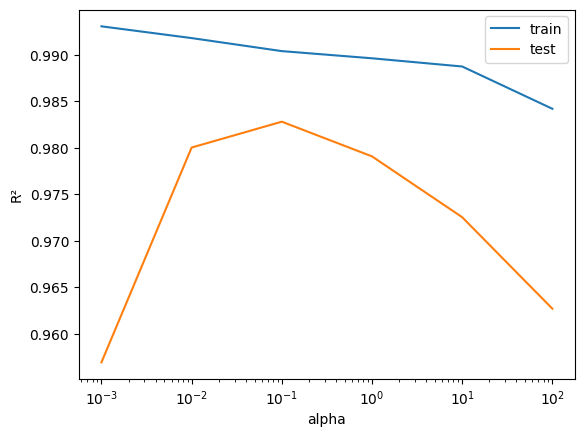

In [101]:
import matplotlib.pyplot as plt

train_score, test_score = [], []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_t)
    train_score.append(ridge.score(train_scaled, train_t))
    test_score.append(ridge.score(test_scaled, test_t))

plt.plot(alpha_list, train_score, label='train')
plt.plot(alpha_list, test_score,  label='test')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R²')
plt.legend()
plt.show()

In [102]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(train_scaled, train_t)
print("train R²:", lasso.score(train_scaled, train_t))  # 0.9898
print("test R²:",  lasso.score(test_scaled, test_t))    # 0.9801
print("0인 계수 수:", np.sum(lasso.coef_ == 0))         # 40~47 (자동 특성 선택)

train R²: 0.9898116789062786
test R²: 0.9801844137326112
0인 계수 수: 47
